In [1]:
!pip install rasterio
print("Se instalo rasterio")

Se instalo rasterio


In [ ]:
!rm -rf /content/drive

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True) #forzar un nuevo montaje

Mounted at /content/drive


In [3]:
 #Para comprobar el tipo de GPU asignada a nuestro portátil, utilizamos el siguiente comando.
!nvidia-smi

Sat Nov 29 04:48:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# ============================================================================
# 1. CONFIGURACIÓN Y PARÁMETROS
# ============================================================================
!pip install rasterio
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Conv3D, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.ndimage import zoom
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import glob
import os
import warnings
warnings.filterwarnings("ignore")

In [5]:
# ======================================================
# OPTIMIZACIÓN GPU PARA GOOGLE COLAB
# ======================================================
from tensorflow.keras import backend as K
K.clear_session()
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU configurada con memory growth habilitado")
    except RuntimeError as e:
        print(e)

✅ GPU configurada con memory growth habilitado


In [6]:

# ======================================================
# PARÁMETROS DE ENTRADA Y SALIDA
# ======================================================
print("\nConfigurando rutas de salida y entrada de datos ...")
ruta_rasters = '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/input2/*.tif'
ruta_salida = '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output/'

target_shape = (90, 124)
row, col = target_shape
n_frames = 12
test_size = 0.2
val_size = 0.1

batch_size = 11
epochs = 50
num_capas = 4

os.makedirs(ruta_salida, exist_ok=True)

print("\nConfigurado ✓✓")


Configurando rutas de salida y entrada de datos ...

Configurado ✓✓


Cargando y redimensionando rasters...
Cargadas 72 imágenes de tamaño (90, 124)
Tamaño de la secuencia: (72, 90, 124)
Tipo de datos: float32
Configurando datos train y test
División temporal: 58 para entrenamiento, 14 para test
Generando 46 secuencias de 12 frames cada una
Generando 2 secuencias de 12 frames cada una
X_train: (46, 12, 90, 124, 1), y_train: (46, 12, 90, 124, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 12, 90, 124,    │        50,764 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 12, 90, 124, 1) │         1,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,912 (1.33 MB)

 Trainable params: 347,912 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50

Epoch 1: val_loss improved from inf to 0.20776, saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output/mejor_modelo.keras
4/4 - 71s - 18s/step - loss: 0.2566 - mae: 0.4163 - val_loss: 0.2078 - val_mae: 0.3482 - learning_rate: 1.0000e-04
Epoch 2/50

Epoch 2: val_loss improved from 0.20776 to 0.20534, saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output/mejor_modelo.keras
4/4 - 8s - 2s/step - loss: 0.2547 - mae: 0.4148 - val_loss: 0.2053 - val_mae: 0.3457 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 3: val_loss improved from 0.20534 to 0.20197, saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output/mejor_modelo.keras
4/4 - 10s - 3s/step - loss: 0.2522 - mae: 0.4126 - val_loss: 0.2020 - val_mae: 0.3416 - learning_rate: 1.0000e-04
Epoch 4/50

Epoch 4: val_loss improved from 0.20197 to 0.19689, saving model to /content/drive/MyDrive/Taller de Complejidad/Per

✅ Modelo guardado correctamente en formato .h5 y .keras


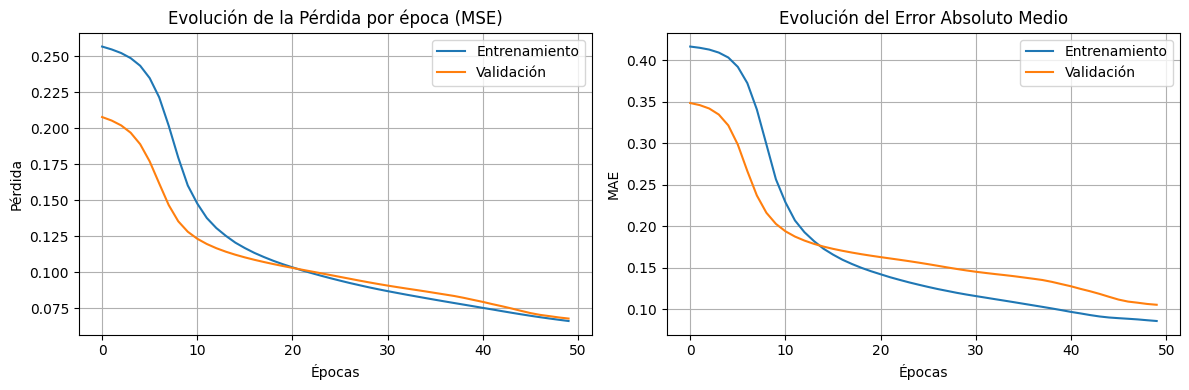

Realizando predicciones en conjunto de prueba...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

MAE global: 0.0918
RMSE global: 0.1147

Calculando métricas espaciales...
IoU entre hotspots predichos y reales: 0.0196
Índice PAI: 0.3843


In [7]:
# ============================================================================
# 2. FUNCIONES AUXILIARES
# ============================================================================

def cargar_y_redimensionar_rasters(ruta_rasters, target_shape):
    """
    Carga y redimensiona las imágenes raster.
    """
    print("Cargando y redimensionando rasters...")
    rasters = sorted(glob.glob(ruta_rasters))
    if len(rasters) == 0:
        raise ValueError(f"No se encontraron archivos en la ruta: {ruta_rasters}")

    sequences = []  #crea la lista de secuencias vacia para almacenar elementos
    for i, raster in enumerate(rasters):
        try: #manejo de excepciones
            with rasterio.open(raster) as src:
                image = src.read(1)
                zoom_factors = (target_shape[0] / image.shape[0], target_shape[1] / image.shape[1])
                resized_image = zoom(image, zoom_factors, order=1)
                sequences.append(resized_image)
        except Exception as e:  #este bloque se ejecuta si el bloque try lanza un error
            print(f"Error procesando {raster}: {e}")
            continue

    sequences = np.array(sequences, dtype=np.float32)
    sequences = sequences / sequences.max()
    print(f"Cargadas {len(sequences)} imágenes de tamaño {target_shape}")
    return sequences

def dividir_datos_temporales(sequences, test_size=0.2):
    """
    Divide los datos manteniendo el orden temporal.
    """
    n_total = len(sequences)
    n_test = int(n_total * test_size)
    train_sequences = sequences[:-n_test]
    test_sequences = sequences[-n_test:]
    print(f"División temporal: {len(train_sequences)} para entrenamiento, {len(test_sequences)} para test")
    return train_sequences, test_sequences


#Genera secuencias para la red ConvLSTM
def generar_secuencias(sequences, n_frames=12):
    """
    Genera secuencias de entrada (X) y objetivo (y) para ConvLSTM.
    """
    n_samples = sequences.shape[0] - n_frames
    if n_samples <= 0:
        raise ValueError(f"No hay suficientes frames. Se necesitan al menos {n_frames + 1} frames.")
    print(f'Generando {n_samples} secuencias de {n_frames} frames cada una')

    X = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    y = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    for i in range(n_samples):
        X[i, :, :, :, 0] = sequences[i:i + n_frames]
        y[i, :, :, :, 0] = sequences[i + 1:i + n_frames + 1]
    return X, y

def crear_modelo_convlstm(input_shape, num_capas=4):
    """
    Crea el modelo ConvLSTM.
    """
    model = Sequential()
    for i in range(num_capas):
        return_sequences = True  # mantenemos secuencia completa para predicción multi-frame
        model.add(ConvLSTM2D(
            filters=37,
            kernel_size=(3, 3),
            input_shape=input_shape if i == 0 else None,
            padding='same',
            return_sequences=return_sequences,
            dropout=0.3,
            recurrent_dropout=0.3,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ))
        #if i < num_capas - 1:
         #   model.add(BatchNormalization())

    model.add(Conv3D(filters=1, kernel_size=(3, 3, 3), activation='sigmoid', padding='same'))
    return model

# ============================================================================
# 3. CARGA Y PREPROCESAMIENTO
# ============================================================================

sequences = cargar_y_redimensionar_rasters(ruta_rasters, target_shape)
print(f"Tamaño de la secuencia: {sequences.shape}")
print(f"Tipo de datos: {sequences.dtype}")
print(f"Configurando datos train y test")
train_sequences, test_sequences = dividir_datos_temporales(sequences, test_size)
X_train, y_train = generar_secuencias(train_sequences, n_frames)
X_test, y_test = generar_secuencias(test_sequences, n_frames)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# ============================================================================
# 4. MODELO Y CALLBACKS
# ============================================================================
input_shape = (n_frames, row, col, 1)
model = crear_modelo_convlstm(input_shape, num_capas)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss='mse',
              metrics=['mae'])

model.summary()

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(ruta_salida, 'mejor_modelo.keras'),
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)
earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ============================================================================
# 5. ENTRENAMIENTO
# ============================================================================
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=val_size,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=2
)

# ============================================================================
# 6. GUARDADO Y VISUALIZACIÓN
# ============================================================================
model.save(os.path.join(ruta_salida, 'modelo_final.h5'))
print("✅ Modelo guardado correctamente en formato .h5 y .keras")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas'); plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida por época (MSE)')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validación')
plt.xlabel('Épocas'); plt.ylabel('MAE')
plt.title('Evolución del Error Absoluto Medio')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig(f'{ruta_salida}entrenamiento_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. EVALUACIÓN GLOBAL
# ============================================================================
print("Realizando predicciones en conjunto de prueba...")
y_pred = model.predict(X_test, verbose=1)

mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
print(f"\nMAE global: {mae:.4f}")
print(f"RMSE global: {rmse:.4f}")

# ============================================================================
# 8. MÉTRICAS ESPACIALES
# ============================================================================
import numpy as np
"""
    Convierte un mapa de calor continuo en un mapa de hotspots binario.

    Define como hotspot (valor 1) a las celdas que están por encima de un
    cierto percentil de densidad.

    Args:
        heatmap (np.array): Array 2D de NumPy con los valores de densidad.
        threshold_percentage (float): El porcentaje del área a ser considerado
                                      como hotspot (ej. 10.0 para el 10% superior).

    Returns:
        np.array: Un array 2D binario (0s y 1s) del mismo tamaño que el heatmap.
    """

def discretize_heatmap(heatmap, threshold_percentage):
    if not (0 < threshold_percentage <= 100):
        raise ValueError("El porcentaje del umbral debe estar entre 0 y 100.")
    # Se calcula el valor de densidad en el percentil deseado.
    # Si queremos el 10% superior, necesitamos el valor en el percentil 90.
    threshold_value = np.percentile(heatmap, 100 - threshold_percentage)
    # Se genera el mapa binario: 1 si el valor de la celda es >= al umbral, 0 en caso contrario.
    return (heatmap >= threshold_value).astype(int)
"""
    Calcula la métrica Intersection over Union (IoU) entre dos mapas de hotspots binarios.

    Args:
        predicted_hotspots (np.array): Mapa binario de los hotspots predichos.
        true_hotspots (np.array): Mapa binario de los hotspots reales.

    Returns:
        float: El valor de IoU (entre 0.0 y 1.0).
    """
def calculate_iou(predicted_hotspots, true_hotspots):
  # La intersección son las celdas donde ambos mapas tienen un 1.
    intersection = np.sum((predicted_hotspots == 1) & (true_hotspots == 1))
    # La unión son las celdas donde al menos un mapa tiene un 1.
    union = np.sum((predicted_hotspots == 1) | (true_hotspots == 1))
     # Manejo de división por cero si no hay hotspots en ningún mapa.
    if union == 0:
        return 1.0 # Si ambos son vacíos, la predicción es perfecta.
    return intersection / union
"""
    Calcula el Índice de Precisión Predictiva (PAI).

    PAI = (% de crímenes en hotspots predichos) / (% de área cubierta por hotspots predichos)

    Args:
        predicted_hotspots (np.array): Mapa binario de los hotspots predichos.
        true_crime_locations (list of tuples): Una lista de coordenadas (fila, col)
                                               de donde ocurrieron los crímenes reales.

    Returns:
        float: El valor de PAI. Un valor > 1.0 indica que el modelo es mejor que el azar.
    """
def calculate_pai(predicted_hotspots, true_crime_locations):
    total_area = predicted_hotspots.size
    hotspot_area = np.sum(predicted_hotspots)
    if hotspot_area == 0:
        return 0.0
    percentage_area = hotspot_area / total_area
    total_crimes = len(true_crime_locations)
    if total_crimes == 0:
        return 0.0
    crimes_in_hotspots = 0
    for r, c in true_crime_locations:
        if 0 <= r < predicted_hotspots.shape[0] and 0 <= c < predicted_hotspots.shape[1]:
            if predicted_hotspots[r, c] == 1:
                crimes_in_hotspots += 1
    percentage_crimes = crimes_in_hotspots / total_crimes
    return percentage_crimes / percentage_area

# ============================================================================
# 9. CÁLCULO DE MÉTRICAS ESPACIALES
# ============================================================================
print("\nCalculando métricas espaciales...")

# Selecciona el último frame del conjunto de prueba y su predicción correspondiente
true_map = y_test[-1, -1, :, :, 0]
pred_map = y_pred[-1, -1, :, :, 0]

# Discretización de mapas (ej. 10% superior)
threshold_percentage = 10
true_hotspots = discretize_heatmap(true_map, threshold_percentage)
pred_hotspots = discretize_heatmap(pred_map, threshold_percentage)

# Calcular IoU
iou = calculate_iou(pred_hotspots, true_hotspots)
print(f"IoU entre hotspots predichos y reales: {iou:.4f}")

# Simulación de coordenadas de delitos reales (si no tienes puntos exactos)
true_crime_locations = np.argwhere(true_hotspots == 1)

# Calcular PAI
pai = calculate_pai(pred_hotspots, true_crime_locations)
print(f"Índice PAI: {pai:.4f}")




#Métricas Espaciales
##IoU ( Intersection over Union)
Mide la precisión espacial de los hotspots. un valor cercano a 1 es ideal (perfecta superposición). Un valor mayor a 0.5 suele considerarse bueno.

##PAI (Predictive Accuracy Index)
Mide la eficiencia del modelo. Un valor de 3.25 significa que el modelo es 3.25 veces mejor que predecir al azar. Un PAI > 1 es el requisito mínimo para que el modelo sea útil

In [ ]:
true_crime_locations

array([[ 0, 22],
       [ 0, 23],
       [ 0, 24],
       ...,
       [73, 35],
       [73, 36],
       [73, 37]])

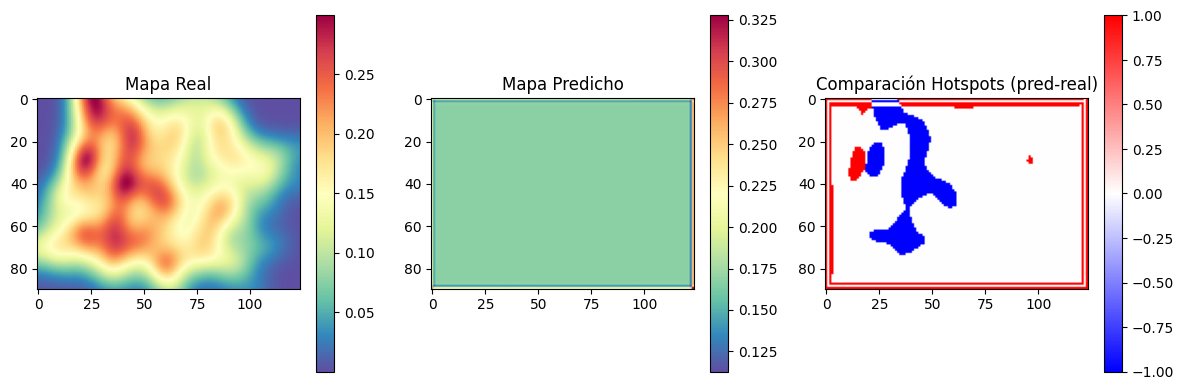

In [8]:

# Visualización de comparación
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(true_map, cmap='Spectral_r',vmin=np.min(true_map),vmax=np.max(true_map)); plt.title('Mapa Real')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(pred_map, cmap='Spectral_r',vmin=np.min(pred_map),vmax=np.max(pred_map)); plt.title('Mapa Predicho')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(pred_hotspots - true_hotspots, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Comparación Hotspots (pred-real)')
plt.tight_layout()
plt.savefig(os.path.join(ruta_salida, f'_map_real_predico_comparacion.png'), dpi=300, bbox_inches='tight')
plt.show()

🧠 CAMBIOS CONCEPTUALES

Tu modelo original solo predecía un frame siguiente (y_test[-1, -1]) respecto a una secuencia de entrada.
Ahora modificaremos el proceso para que genere 12 frames futuros de forma autoregresiva, es decir:

Usamos una secuencia inicial de 12 meses reales (track = 12 frames).

El modelo predice el siguiente mes (new_pos) usando model.predict(track[np.newaxis, ...]).

El último frame de esa predicción (new = new_pos[:, -1, ...]) se agrega al track.

Repetimos este ciclo 12 veces → obtenemos 12 meses futuros predichos.

Durante la evaluación:

Calcularemos IoU y PAI para cada frame predicho, comparándolo con su contraparte real (si existe).

Luego mostraremos los promedios temporales de ambas métricas.

⚙️ CAMBIOS TÉCNICOS (bloques modificados y nuevos)

Nuevo bloque 8: predicción autoregresiva de 12 meses (prediccion_temporal).

Nuevo bloque 9: evaluación temporal completa (IoU, PAI por mes y promedios).

Se usa la misma arquitectura y entrenamiento previos.

Se mantienen las métricas globales (MAE y RMSE).

In [9]:
# ============================================================================
# 2. FUNCIONES AUXILIARES
# ============================================================================

def cargar_y_redimensionar_rasters(ruta_rasters, target_shape):
    """
    Carga y redimensiona las imágenes raster.
    """
    print("Cargando y redimensionando rasters...")
    rasters = sorted(glob.glob(ruta_rasters))
    if len(rasters) == 0:
        raise ValueError(f"No se encontraron archivos en la ruta: {ruta_rasters}")

    sequences = []  #crea la lista de secuencias vacia para almacenar elementos
    for i, raster in enumerate(rasters):
        try: #manejo de excepciones
            with rasterio.open(raster) as src:
                image = src.read(1)
                zoom_factors = (target_shape[0] / image.shape[0], target_shape[1] / image.shape[1])
                resized_image = zoom(image, zoom_factors, order=1)
                sequences.append(resized_image)
        except Exception as e:  #este bloque se ejecuta si el bloque try lanza un error
            print(f"Error procesando {raster}: {e}")
            continue

    sequences = np.array(sequences, dtype=np.float32)
    sequences = sequences / sequences.max()
    print(f"Cargadas {len(sequences)} imágenes de tamaño {target_shape}")
    return sequences

def dividir_datos_temporales(sequences, test_size=0.2):
    """
    Divide los datos manteniendo el orden temporal.
    """
    n_total = len(sequences)
    n_test = int(n_total * test_size)
    train_sequences = sequences[:-n_test]
    test_sequences = sequences[-n_test:]
    print(f"División temporal: {len(train_sequences)} para entrenamiento, {len(test_sequences)} para test")
    return train_sequences, test_sequences


#Genera secuencias para la red ConvLSTM
def generar_secuencias(sequences, n_frames=12):
    """
    Genera secuencias de entrada (X) y objetivo (y) para ConvLSTM.
    """
    n_samples = sequences.shape[0] - n_frames
    if n_samples <= 0:
        raise ValueError(f"No hay suficientes frames. Se necesitan al menos {n_frames + 1} frames.")
    print(f'Generando {n_samples} secuencias de {n_frames} frames cada una')

    X = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    y = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    for i in range(n_samples):
        X[i, :, :, :, 0] = sequences[i:i + n_frames]
        y[i, :, :, :, 0] = sequences[i + 1:i + n_frames + 1]
    return X, y

def crear_modelo_convlstm(input_shape, num_capas=4):
""" Crea el modelo ConvLSTM.
Se inicializa un modelo secuencial de Keras, que permite apilar capas en secuencia.
Creamos una capa que toma como entrada películas de forma (n_fotogramas, ancho, alto, canales) y
devuelve una película de forma idéntica.
Se añaden varias capas ConvLSTM2D con la misma configuración y una capa de normalización tras cada una.
Esto permite que el modelo aprenda patrones complejos y profundos en secuencias temporales. """

    model = Sequential()
    for i in range(num_capas):
        return_sequences = True  # mantenemos secuencia completa para predicción multi-frame
        model.add(ConvLSTM2D(
            filters=37,
            kernel_size=(3, 3),
            input_shape=input_shape if i == 0 else None,
            padding='same',
            return_sequences=return_sequences,
            dropout=0.3,
            recurrent_dropout=0.3,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ))
        if i < num_capas - 1:
            model.add(BatchNormalization())

    model.add(Conv3D(filters=1, kernel_size=(3, 3, 3), activation='sigmoid', padding='same'))
    return model

# ============================================================================
# 3. CARGA Y PREPROCESAMIENTO
# ============================================================================

sequences = cargar_y_redimensionar_rasters(ruta_rasters, target_shape)
print(f"Tamaño de la secuencia: {sequences.shape}")
print(f"Tipo de datos: {sequences.dtype}")
print(f"Configurando datos train y test")
train_sequences, test_sequences = dividir_datos_temporales(sequences, test_size)
X_train, y_train = generar_secuencias(train_sequences, n_frames)
X_test, y_test = generar_secuencias(test_sequences, n_frames)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# ============================================================================
# 4. MODELO Y CALLBACKS
# ============================================================================

input_shape = (n_frames, row, col, 1)
model = crear_modelo_convlstm(input_shape, num_capas)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss='mse',
              metrics=['mae'])

model.summary()

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(ruta_salida, 'mejor_modelo.keras'),
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)
earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ============================================================================
# 5. ENTRENAMIENTO
# ============================================================================
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=val_size,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=2
)

# ============================================================================
# 6. GUARDADO Y VISUALIZACIÓN
# ============================================================================
model.save(os.path.join(ruta_salida, 'modelo_final.h5'))
print("✅ Modelo guardado correctamente en formato .h5 y .keras")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas'); plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida por época (MSE)')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validación')
plt.xlabel('Épocas'); plt.ylabel('MAE')
plt.title('Evolución del Error Absoluto Medio')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig(f'{ruta_salida}entrenamiento_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. EVALUACIÓN GLOBAL
# ============================================================================
print("Realizando predicciones en conjunto de prueba...")
y_pred = model.predict(X_test, verbose=1)

mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
print(f"\nMAE global: {mae:.4f}")
print(f"RMSE global: {rmse:.4f}")


IndentationError: expected an indented block after function definition on line 60 (ipython-input-124019784.py, line 61)

🔍 EXPLICACIÓN DE CAMBIO CLAVE

La parte fundamental es este bloque:

for j in range(12):  
    new_pos = model.predict(track[np.newaxis, :, :, :, :])  
    new_frame = new_pos[:, -1, :, :, :]  
    track = np.concatenate((track[1:], new_frame[0:1]), axis=0)


track[np.newaxis, ...] → agrega dimensión batch (1, 12, H, W, 1).

new_pos → predicción completa (1, 12, H, W, 1).

new_pos[:, -1, :, :, :] → selecciona solo el último frame de la secuencia predicha (el siguiente mes).

track = np.concatenate((track[1:], new_frame[0:1]), axis=0) → elimina el primer mes (más antiguo) y agrega el nuevo frame.
→ Esto convierte el modelo en un predictor autoregresivo de horizonte múltiple.


🔁 Generando predicciones autoregresivas para 12 meses...
Secuencia predicha con forma: (12, 90, 124, 1)

📊 Calculando métricas espaciales para cada mes predicho...

Métricas promedio en 12 meses:
IoU medio: 0.0203
PAI medio: 0.3981


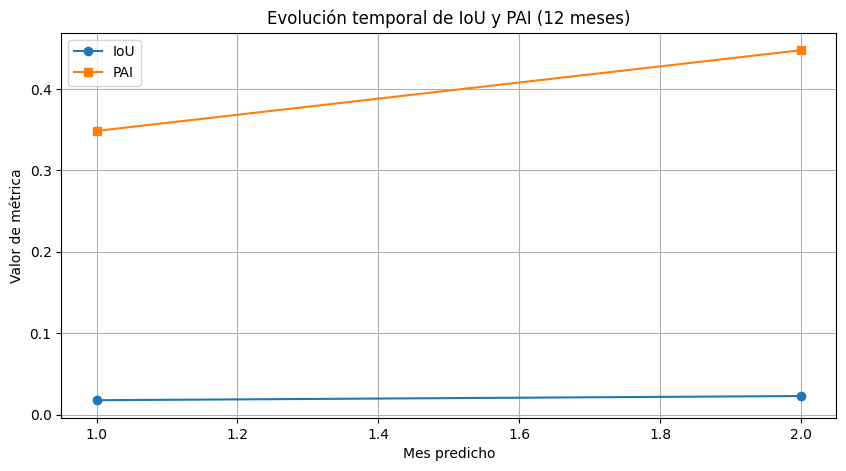

In [10]:

# ============================================================================
# 8. PREDICCIÓN AUTORREGRESIVA DE 12 MESES (1 AÑO)
# ============================================================================
print("\n🔁 Generando predicciones autoregresivas para 12 meses...")

# Usamos la última secuencia del conjunto de prueba como punto de partida
track = X_test[-1].copy()  # shape (12, row, col, 1)

predicted_sequence = []

#  🔍 CAMBIO CLAVE
for j in range(12):  # 12 meses predichos hacia adelante
    new_pos = model.predict(track[np.newaxis, :, :, :, :], verbose=0)  # (1, 12, row, col, 1)
    new_frame = new_pos[:, -1, :, :, :]  # tomamos el último frame predicho
    predicted_sequence.append(new_frame[0])
    # actualizamos el track eliminando el primer frame y añadiendo el nuevo
    track = np.concatenate((track[1:], new_frame[0:1]), axis=0)

predicted_sequence = np.array(predicted_sequence)  # (12, row, col, 1)
print(f"Secuencia predicha con forma: {predicted_sequence.shape}")

# Guardar predicciones individuales como imágenes
for i in range(12):
    plt.figure(figsize=(6,4))
    plt.imshow(predicted_sequence[i, :, :, 0], cmap='Spectral_r', vmin=np.min(predicted_sequence), vmax=np.max(predicted_sequence))
    plt.title(f"Predicción Mes {i+1}")
    plt.colorbar()
    plt.axis('off')
    plt.savefig(os.path.join(ruta_salida, f"prediccion_mes_{i+1}.png"), dpi=200, bbox_inches='tight')
    plt.close()

# ============================================================================
# 9. MÉTRICAS ESPACIALES (EVALUACIÓN TEMPORAL)
# ============================================================================
import numpy as np

def discretize_heatmap(heatmap, threshold_percentage):
    if not (0 < threshold_percentage <= 100):
        raise ValueError("El porcentaje del umbral debe estar entre 0 y 100.")
    threshold_value = np.percentile(heatmap, 100 - threshold_percentage)
    return (heatmap >= threshold_value).astype(int)

def calculate_iou(predicted_hotspots, true_hotspots):
    intersection = np.sum((predicted_hotspots == 1) & (true_hotspots == 1))
    union = np.sum((predicted_hotspots == 1) | (true_hotspots == 1))
    if union == 0:
        return 1.0
    return intersection / union

def calculate_pai(predicted_hotspots, true_crime_locations):
    total_area = predicted_hotspots.size
    hotspot_area = np.sum(predicted_hotspots)
    if hotspot_area == 0:
        return 0.0
    percentage_area = hotspot_area / total_area
    total_crimes = len(true_crime_locations)
    if total_crimes == 0:
        return 0.0
    crimes_in_hotspots = 0
    for r, c in true_crime_locations:
        if 0 <= r < predicted_hotspots.shape[0] and 0 <= c < predicted_hotspots.shape[1]:
            if predicted_hotspots[r, c] == 1:
                crimes_in_hotspots += 1
    percentage_crimes = crimes_in_hotspots / total_crimes
    return percentage_crimes / percentage_area

# Evaluación temporal
print("\n📊 Calculando métricas espaciales para cada mes predicho...")
threshold_percentage = 10
ious, pais = [], []

for t in range(min(12, y_test.shape[0])):  # hasta 12 frames o los disponibles
    true_map = y_test[t, -1, :, :, 0]
    pred_map = predicted_sequence[t, :, :, 0]

    true_hotspots = discretize_heatmap(true_map, threshold_percentage)
    pred_hotspots = discretize_heatmap(pred_map, threshold_percentage)

    iou = calculate_iou(pred_hotspots, true_hotspots)
    ious.append(iou)

    true_crime_locations = np.argwhere(true_hotspots == 1)
    pai = calculate_pai(pred_hotspots, true_crime_locations)
    pais.append(pai)

# Promedios
iou_mean = np.mean(ious)
pai_mean = np.mean(pais)
print(f"\nMétricas promedio en 12 meses:")
print(f"IoU medio: {iou_mean:.4f}")
print(f"PAI medio: {pai_mean:.4f}")

# Gráficos de evolución temporal
plt.figure(figsize=(10,5))
plt.plot(range(1, len(ious)+1), ious, marker='o', label='IoU')
plt.plot(range(1, len(pais)+1), pais, marker='s', label='PAI')
plt.title('Evolución temporal de IoU y PAI (12 meses)')
plt.xlabel('Mes predicho')
plt.ylabel('Valor de métrica')
plt.legend(); plt.grid(True)
plt.savefig(os.path.join(ruta_salida, 'metricas_temporales.png'), dpi=300, bbox_inches='tight')
plt.show()
